# EDA for Entrained Droplet Fraction Dataset

In [1]:
#Imports
import math, os, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.stats import zscore
import pandas as pd
import random

#File path 
df = pd.read_csv(r"../../data/entraineddropletfraction_VerticalFlow.csv")

In [2]:
# quick peek
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nFirst 5 rows:\n", df.head())

# data quality
print("\nMissing values per column:")
print(df.isna().sum())

# duplicates
dup_count = df.duplicated().sum()
print("\nDuplicate rows:", dup_count)

# dtypes
print("\nDtypes:\n", df.dtypes)

Shape: (1367, 9)
Columns: ['D', 'Usg', 'UsL', 'rhol', 'rhog', 'st', 'MuL', 'Mug', 'e']

First 5 rows:
         D    Usg  UsL   rhol   rhog    st       MuL       Mug     e
0  0.1016  18.39  0.1  997.0  1.184  0.07  0.000894  0.000019  0.63
1  0.1016  23.66  0.1  997.0  1.184  0.07  0.000894  0.000019  0.61
2  0.1016  28.87  0.1  997.0  1.184  0.07  0.000894  0.000019  0.67
3  0.1016   9.17  0.2  997.0  1.184  0.07  0.000894  0.000019  0.64
4  0.1016  12.08  0.2  997.0  1.184  0.07  0.000894  0.000019  0.63

Missing values per column:
D       0
Usg     0
UsL     0
rhol    0
rhog    0
st      0
MuL     0
Mug     0
e       0
dtype: int64

Duplicate rows: 45

Dtypes:
 D       float64
Usg     float64
UsL     float64
rhol    float64
rhog    float64
st      float64
MuL     float64
Mug     float64
e       float64
dtype: object


In [3]:
#Basic statistics
# numeric summary
desc = df.describe().T
print("\nDescriptive statistics:\n", desc)

# target stats
TARGET_COL = "e"
if TARGET_COL in df.columns:
    print("\nTarget summary:")
    print(df[TARGET_COL].describe())


Descriptive statistics:
        count        mean         std         min         25%         50%  \
D     1367.0    0.025928    0.028774    0.005000    0.010000    0.014000   
Usg   1367.0   34.694955   24.762077    1.390000   15.969985   25.057082   
UsL   1367.0    0.565533    1.274229    0.005115    0.084000    0.233224   
rhol  1367.0  992.806203  162.352849  710.000000  997.000000  997.000000   
rhog  1367.0   11.119233   15.611366    1.184000    1.380000    2.841600   
st    1367.0    0.056606    0.024444    0.005860    0.070000    0.070000   
MuL   1367.0    0.001204    0.001506    0.000020    0.000894    0.000894   
Mug   1367.0    0.000027    0.000061    0.000010    0.000019    0.000019   
e     1367.0    0.456581    0.288939    0.003000    0.191924    0.430000   

             75%          max  
D       0.031800     0.127000  
Usg    47.719595   116.000000  
UsL     0.550628    11.515033  
rhol  997.000000  1487.004000  
rhog   22.220000    88.046000  
st      0.070000     

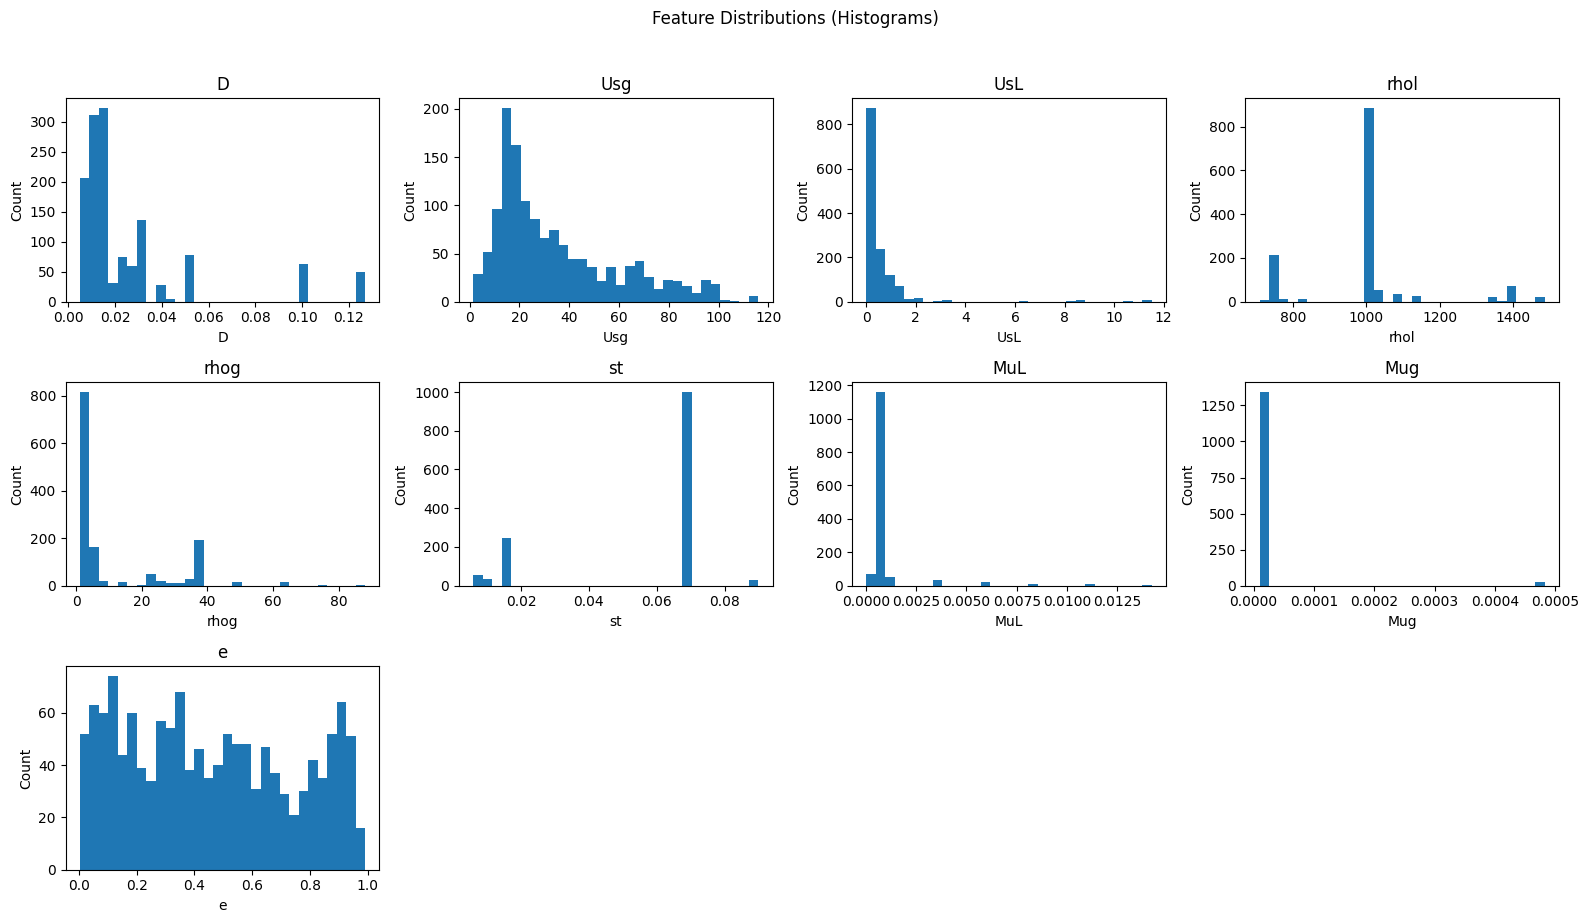

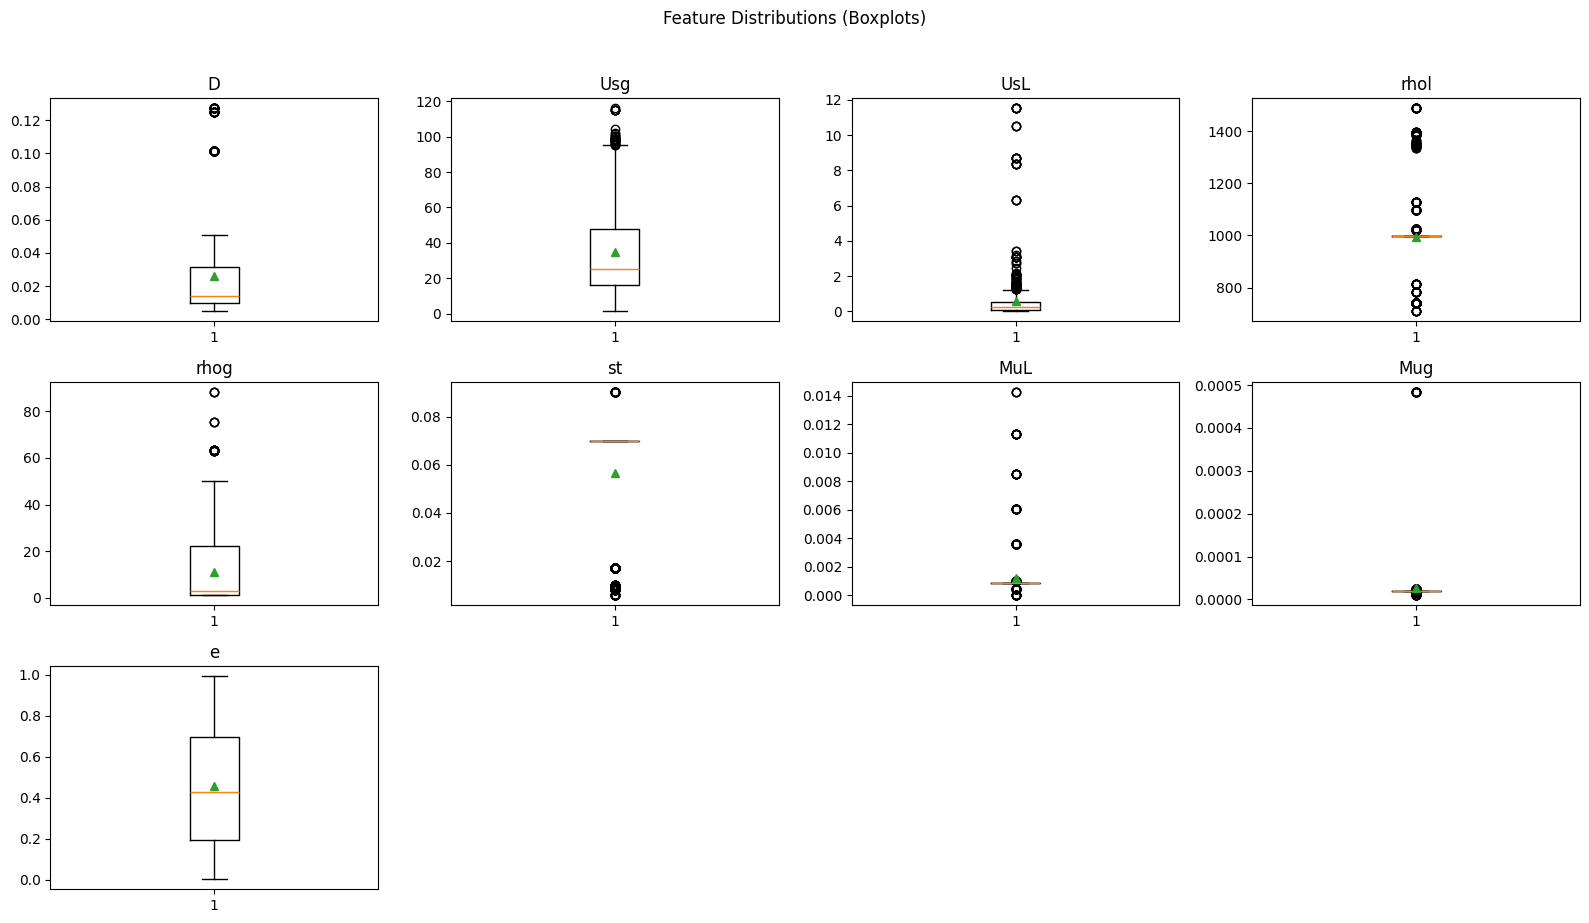

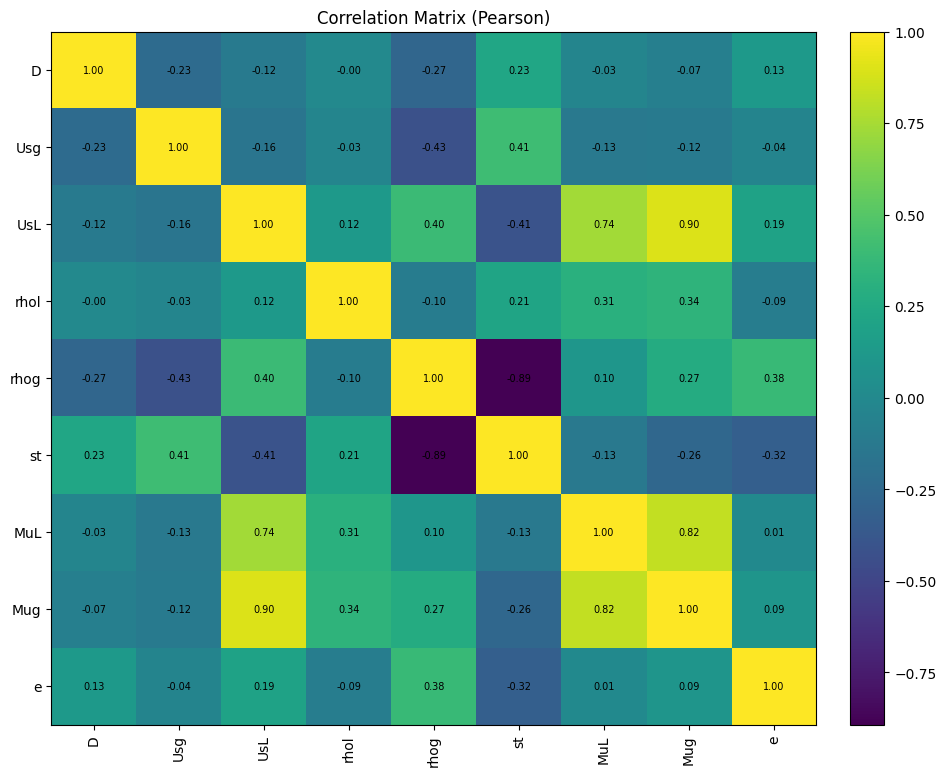

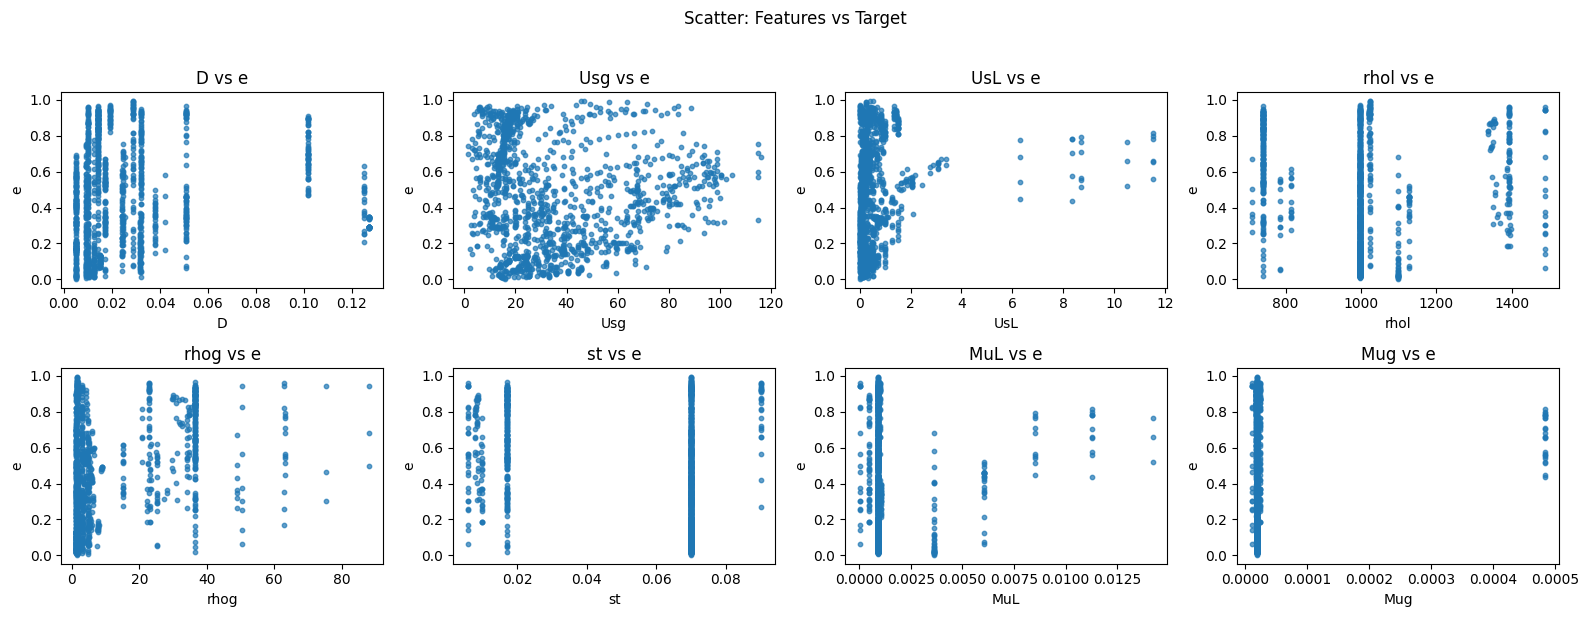

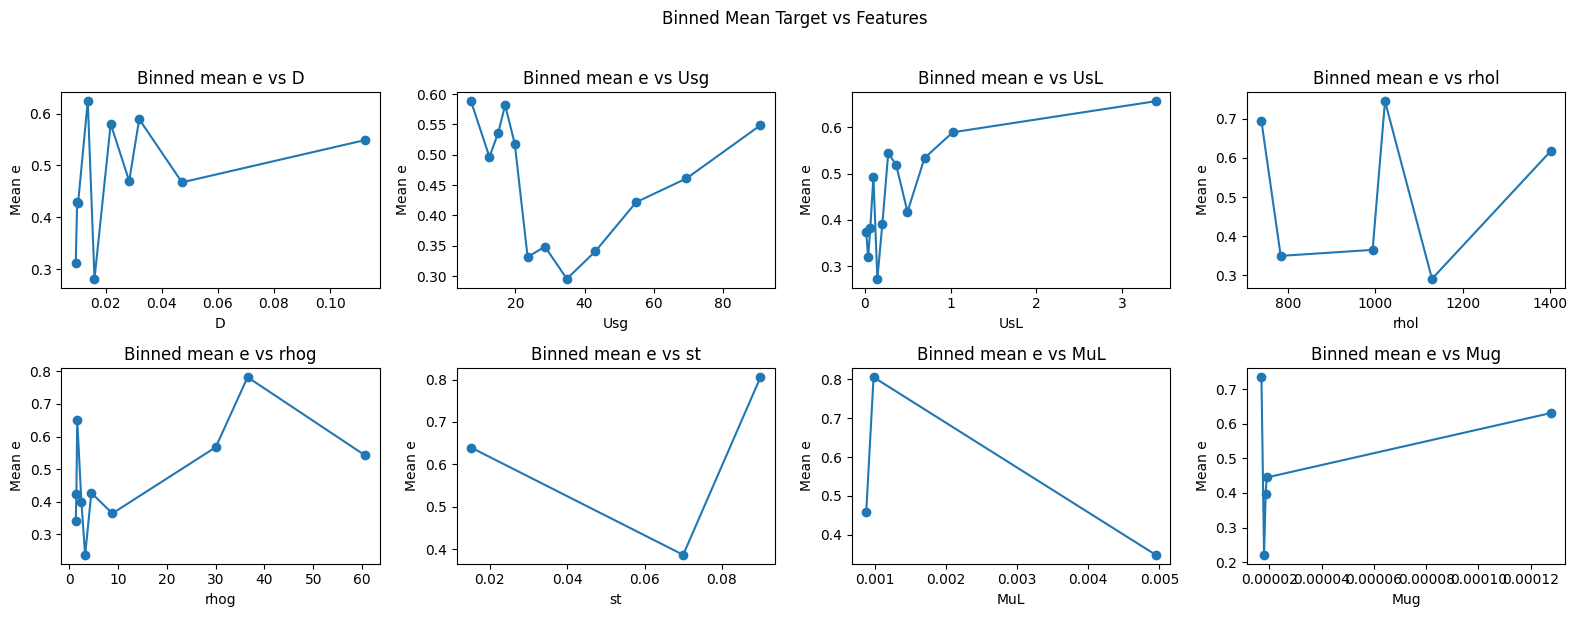


Potential outliers (|z|>3): 124
Outlier fraction: 9.07%


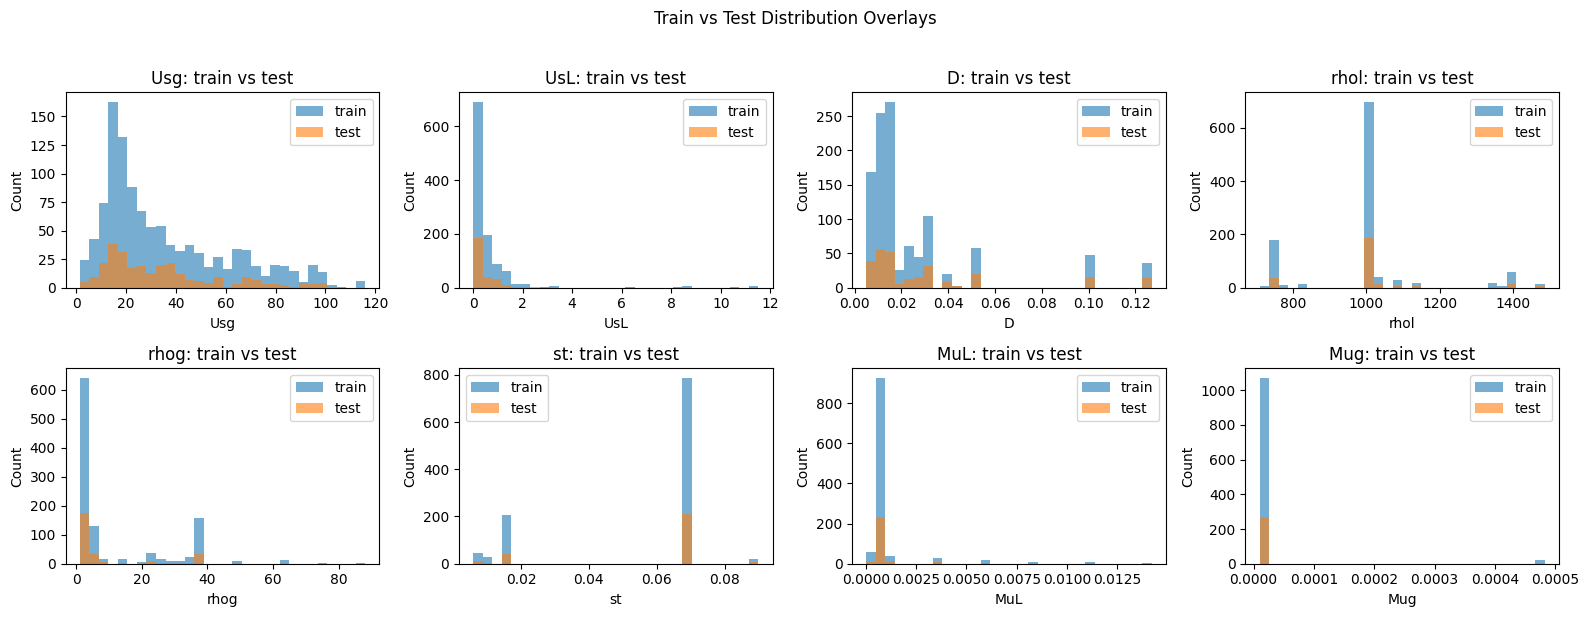

In [4]:
# Multi panel figures

SAVE_FIGS = False
FIG_DIR   = "./eda_figures"
RANDOM_STATE = 13

if SAVE_FIGS and not os.path.exists(FIG_DIR):
    os.makedirs(FIG_DIR, exist_ok=True)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
features = [c for c in numeric_cols if c != TARGET_COL]

def _grid(n, max_cols=4):
    cols = min(max_cols, n)
    rows = math.ceil(n / cols)
    return rows, cols

# Histograms (all numeric) on one figure
rows, cols = _grid(len(numeric_cols), max_cols=4)
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
axes = np.array(axes).reshape(rows, cols)

for i, col in enumerate(numeric_cols):
    r, c = divmod(i, cols)
    ax = axes[r, c]
    ax.hist(df[col].values, bins=30)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

# hide any empty subplots
for j in range(len(numeric_cols), rows*cols):
    r, c = divmod(j, cols)
    axes[r, c].axis("off")

fig.suptitle("Feature Distributions (Histograms)", y=1.02)
fig.tight_layout()
if SAVE_FIGS: fig.savefig(os.path.join(FIG_DIR, "histograms_grid.png"), bbox_inches="tight")
plt.show()

# Boxplots (all numeric) on one figure
rows, cols = _grid(len(numeric_cols), max_cols=4)
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
axes = np.array(axes).reshape(rows, cols)

for i, col in enumerate(numeric_cols):
    r, c = divmod(i, cols)
    ax = axes[r, c]
    ax.boxplot(df[col].values, vert=True, showmeans=True)
    ax.set_title(col)

for j in range(len(numeric_cols), rows*cols):
    r, c = divmod(j, cols)
    axes[r, c].axis("off")

fig.suptitle("Feature Distributions (Boxplots)", y=1.02)
fig.tight_layout()
if SAVE_FIGS: fig.savefig(os.path.join(FIG_DIR, "boxplots_grid.png"), bbox_inches="tight")
plt.show()

#Correlation matrix (single canvas)

corr = df[numeric_cols].corr(method="pearson")
plt.figure(figsize=(1.2*len(numeric_cols), 1.0*len(numeric_cols)))
im = plt.imshow(corr.values, aspect='auto', interpolation='nearest')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation Matrix (Pearson)")

# annotate
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        val = corr.values[i, j]
        plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7)

if SAVE_FIGS: plt.savefig(os.path.join(FIG_DIR, "corr_matrix.png"), bbox_inches="tight")
plt.show()

#Target vs feature scatterplots on one figure
rows, cols = _grid(len(features), max_cols=4)
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
axes = np.array(axes).reshape(rows, cols)

for i, col in enumerate(features):
    r, c = divmod(i, cols)
    ax = axes[r, c]
    ax.scatter(df[col].values, df[TARGET_COL].values, s=10, alpha=0.7)
    ax.set_title(f"{col} vs {TARGET_COL}")
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET_COL)

for j in range(len(features), rows*cols):
    r, c = divmod(j, cols)
    axes[r, c].axis("off")

fig.suptitle("Scatter: Features vs Target", y=1.02)
fig.tight_layout()
if SAVE_FIGS: fig.savefig(os.path.join(FIG_DIR, "scatter_vs_target_grid.png"), bbox_inches="tight")
plt.show()

# Binned mean target vs features on one figure
def binned_relationship(x, y, bins=12):
    x = np.asarray(x); y = np.asarray(y)
    q = np.linspace(0, 1, bins+1)
    edges = np.quantile(x, q)
    edges = np.unique(edges)
    if len(edges) < 3:
        return None, None
    idx = np.digitize(x, edges, right=True) - 1
    bx, by = [], []
    for b in range(len(edges)-1):
        m = (idx == b)
        if m.any():
            bx.append(x[m].mean())
            by.append(y[m].mean())
    return np.array(bx), np.array(by)

rows, cols = _grid(len(features), max_cols=4)
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
axes = np.array(axes).reshape(rows, cols)

for i, col in enumerate(features):
    r, c = divmod(i, cols)
    ax = axes[r, c]
    bx, by = binned_relationship(df[col].values, df[TARGET_COL].values, bins=12)
    if bx is not None:
        ax.plot(bx, by, marker="o")
    ax.set_title(f"Binned mean {TARGET_COL} vs {col}")
    ax.set_xlabel(col); ax.set_ylabel(f"Mean {TARGET_COL}")

for j in range(len(features), rows*cols):
    r, c = divmod(j, cols)
    axes[r, c].axis("off")

fig.suptitle("Binned Mean Target vs Features", y=1.02)
fig.tight_layout()
if SAVE_FIGS: fig.savefig(os.path.join(FIG_DIR, "binned_mean_grid.png"), bbox_inches="tight")
plt.show()

#Basic outlier flags via Z-score
zdf = df[numeric_cols].apply(zscore)
outlier_mask = (np.abs(zdf) > 3).any(axis=1)
print("\nPotential outliers (|z|>3):", int(outlier_mask.sum()))
print("Outlier fraction: {:.2%}".format(outlier_mask.mean()))

#Train/Test split overlays on one figure
X = df[features]
y = df[TARGET_COL]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)

def train_test_overlay_grid(cols_to_plot, max_cols=3):
    rows, cols = _grid(len(cols_to_plot), max_cols=max_cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
    axes = np.array(axes).reshape(rows, cols)
    for i, col in enumerate(cols_to_plot):
        r, c = divmod(i, cols)
        ax = axes[r, c]
        combined = np.concatenate([X_train[col].values, X_test[col].values])
        bins = np.histogram_bin_edges(combined, bins=30)
        ax.hist(X_train[col].values, bins=bins, alpha=0.6, label="train")
        ax.hist(X_test[col].values, bins=bins, alpha=0.6, label="test")
        ax.set_title(f"{col}: train vs test")
        ax.set_xlabel(col); ax.set_ylabel("Count")
        ax.legend()
    for j in range(len(cols_to_plot), rows*cols):
        r, c = divmod(j, cols)
        axes[r, c].axis("off")
    fig.suptitle("Train vs Test Distribution Overlays", y=1.02)
    fig.tight_layout()
    return fig

cols_of_interest = [c for c in ["Usg","UsL","D","rhol","rhog","st","MuL","Mug"] if c in X_train.columns]
fig = train_test_overlay_grid(cols_of_interest, max_cols=4)
if SAVE_FIGS: fig.savefig(os.path.join(FIG_DIR, "train_test_overlays_grid.png"), bbox_inches="tight")
plt.show()


# 2nd EDA Pass: Derived Dimensionless Features

Dimensionless Parameters in Fluid Mechanics
Reynolds number: Re
Mach number: Ma
Weber number: We
Strouhal number: St

Used to characterize laminar/turbulent flow, compressible flow, open channel flow, flows with strong surface tension effects, oscillating flows

In [6]:
# Dimensionless Features
df_dim = df.copy()

# Liquid Reynolds number: (rho_l * Usl * D) / mu_l
df_dim["Re_l"] = (df_dim["rhol"] * df_dim["UsL"] * df_dim["D"]) / df_dim["MuL"]

# Gas Reynolds number: (rho_g * Usg * D) / mu_g
df_dim["Re_g"] = (df_dim["rhog"] * df_dim["Usg"] * df_dim["D"]) / df_dim["Mug"]

# Gas Weber number: (rho_g * Usg^2 * D) / sigma
df_dim["We_g"] = (df_dim["rhog"] * (df_dim["Usg"]**2) * df_dim["D"]) / df_dim["st"]
#sanity check
print(df_dim[["Re_l","Re_g","We_g"]].describe())

                Re_l          Re_g          We_g
count    1367.000000  1.367000e+03   1367.000000
mean    11686.562818  1.777693e+05   3236.048620
std     29785.054187  1.872082e+05   5311.513731
min        45.708333  5.106111e+03      3.320297
25%      1249.038031  4.999271e+04    385.645714
50%      3785.466038  1.032511e+05   1157.360979
75%     10499.999990  2.382580e+05   4089.786744
max    494969.999529  1.214286e+06  66661.778144


#### Histograms for raw + dimensionless features

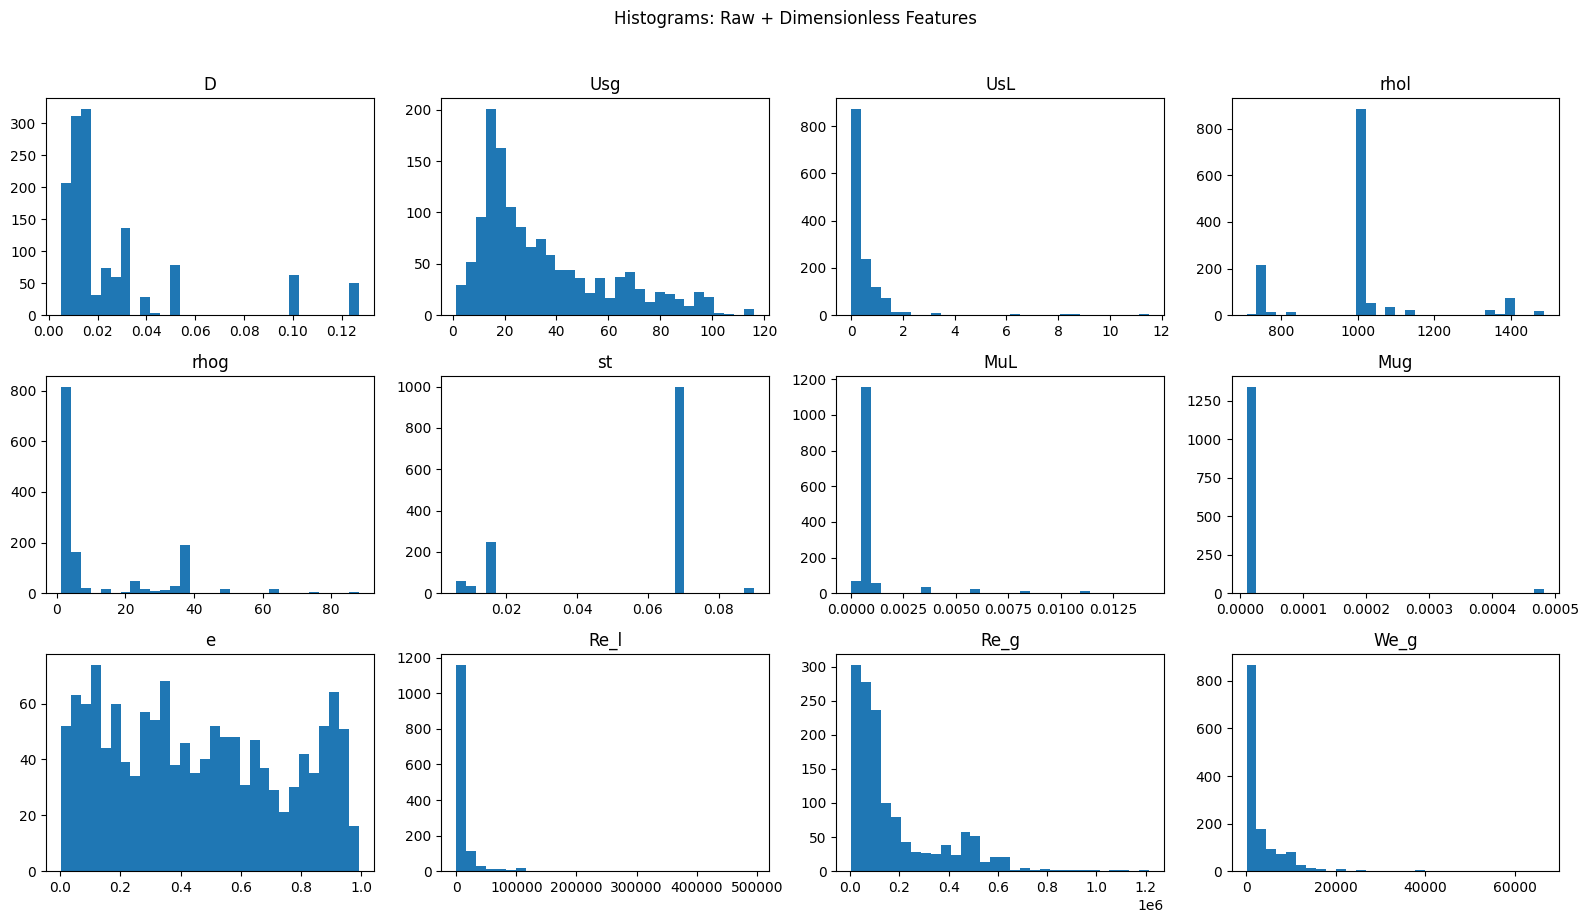

In [7]:
# Combine raw numeric + new features
num_cols_dim = [c for c in df_dim.select_dtypes(include=[np.number]).columns]

rows, cols = _grid(len(num_cols_dim), max_cols=4)
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
axes = np.array(axes).reshape(rows, cols)

for i, col in enumerate(num_cols_dim):
    r, c = divmod(i, cols)
    ax = axes[r, c]
    ax.hist(df_dim[col].values, bins=30)
    ax.set_title(col)

for j in range(len(num_cols_dim), rows*cols):
    r, c = divmod(j, cols)
    axes[r, c].axis("off")

fig.suptitle("Histograms: Raw + Dimensionless Features", y=1.02)
fig.tight_layout()
plt.show()

#### Scatter VS Target (e) for dimensionless groups

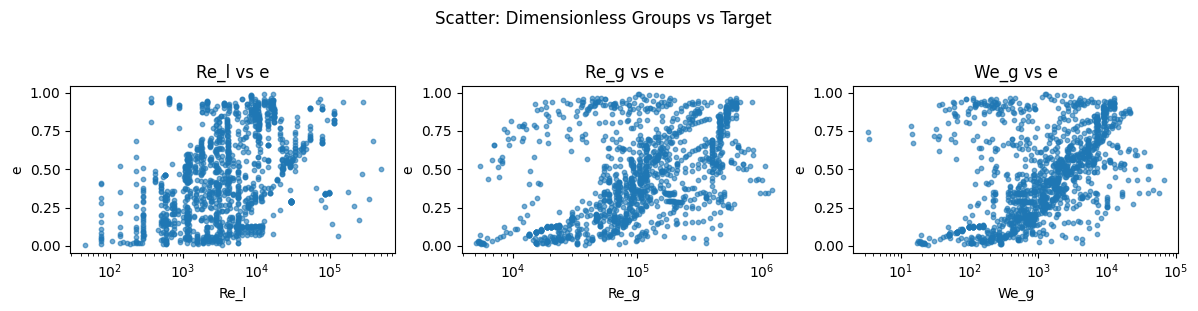

In [8]:
dim_feats = ["Re_l","Re_g","We_g"]

rows, cols = _grid(len(dim_feats), max_cols=3)
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
axes = np.array(axes).reshape(rows, cols)

for i, col in enumerate(dim_feats):
    r, c = divmod(i, cols)
    ax = axes[r, c]
    ax.scatter(df_dim[col].values, df_dim["e"].values, s=10, alpha=0.6)
    ax.set_xscale("log")   # standard for Re, We
    ax.set_title(f"{col} vs e")
    ax.set_xlabel(col); ax.set_ylabel("e")

fig.suptitle("Scatter: Dimensionless Groups vs Target", y=1.02)
fig.tight_layout()
plt.show()


#### Correlation comparison

In [10]:
# correlations
raw_corrs = df.corr()["e"].drop("e").sort_values(ascending=False)
dim_corrs = df_dim[["Re_l","Re_g","We_g","e"]].corr()["e"].drop("e")

print("Raw feature correlations:\n", raw_corrs, "\n")
print("Dimensionless correlations:\n", dim_corrs, "\n")

# side-by-side DataFrame
comparison = pd.DataFrame({
    "Raw Corr": raw_corrs,
    "Dimless Corr": dim_corrs
})
print(comparison)


Raw feature correlations:
 rhog    0.380830
UsL     0.194763
D       0.128229
Mug     0.093436
MuL     0.006870
Usg    -0.039588
rhol   -0.087144
st     -0.322537
Name: e, dtype: float64 

Dimensionless correlations:
 Re_l    0.157510
Re_g    0.438543
We_g    0.335520
Name: e, dtype: float64 

      Raw Corr  Dimless Corr
D     0.128229           NaN
MuL   0.006870           NaN
Mug   0.093436           NaN
Re_g       NaN      0.438543
Re_l       NaN      0.157510
UsL   0.194763           NaN
Usg  -0.039588           NaN
We_g       NaN      0.335520
rhog  0.380830           NaN
rhol -0.087144           NaN
st   -0.322537           NaN


Raw features
rhog (gas density) has the strongest raw correlation with entrainment fraction e (~0.38)

st (surface tension) is moderately negative (~-0.32)

Velocities (UsL, Usg) show weaker linear correlation, but we know from the scatterplots that relationships are nonlinear (trees/ANN perform better)

Dimensionless Groups
Re_g (gas Reynolds) has the strongest correlation overall ~0.44 

We_g (gas Weber) is also slightly correlated ~0.34

Re_l (liquid Reynolds) is weak ~0.16

dimensionless groups compress the physics, raw features best for prediction (as the paper showed)

Dimensionless groups best for interpretability



#### Basic Machine Learning Comparison Raw vs. Dimensionless features

In [11]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

In [12]:
X_raw = df.drop(columns=["e"]).values
y     = df["e"].values  # 1D for sklearn

X_dim = df_dim[["Re_l","Re_g","We_g"]].values

In [13]:
def make_pipeline_if_needed(model, needs_scaling: bool):
    return Pipeline([("scaler", StandardScaler()), ("model", model)]) if needs_scaling else model

models = {
    "Linear Regression":            (LinearRegression(), True),
    "Decision Tree (coarse)":       (DecisionTreeRegressor(max_depth=5, random_state=42), False),
    "SVM (Cubic)":                  (SVR(kernel="poly", degree=3, C=10, epsilon=0.01), True),
    "Random Forest":                (RandomForestRegressor(random_state=42, n_estimators=200), False),
    "Gradient Boosting":            (GradientBoostingRegressor(random_state=42, n_estimators=200), True),
    "Gaussian Process (RBF)":       (GaussianProcessRegressor(kernel=RBF(), alpha=1e-2, random_state=42), True),
}

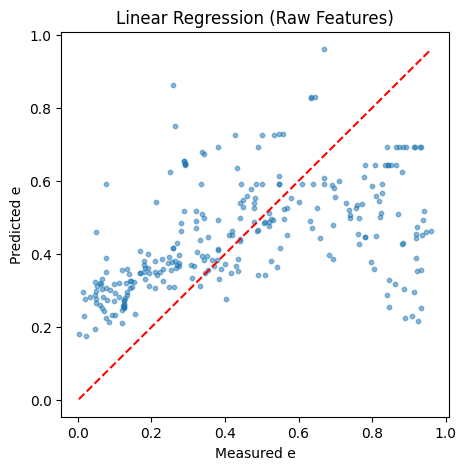

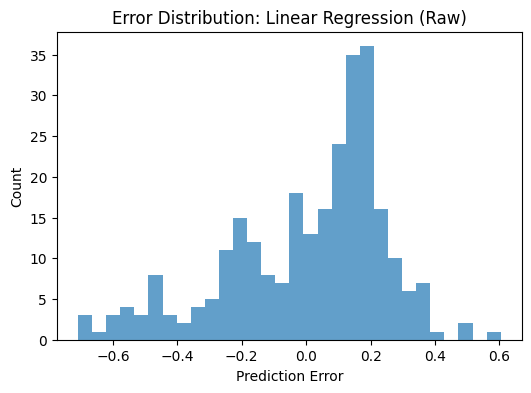

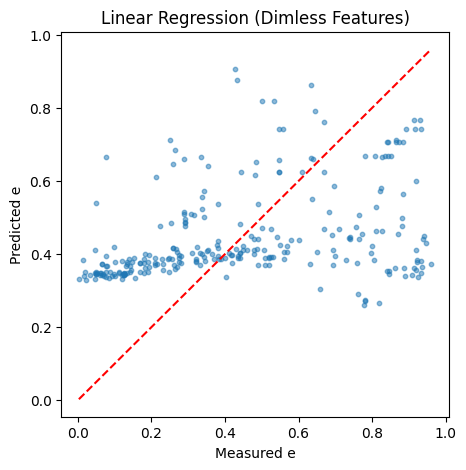

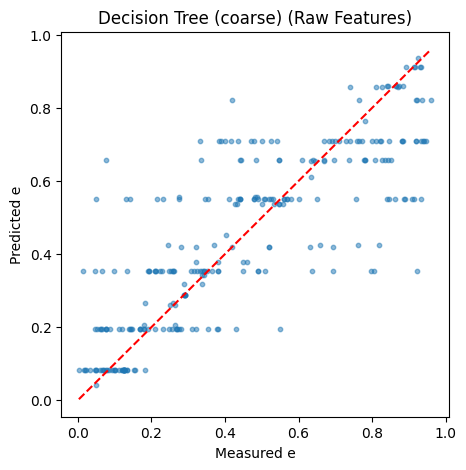

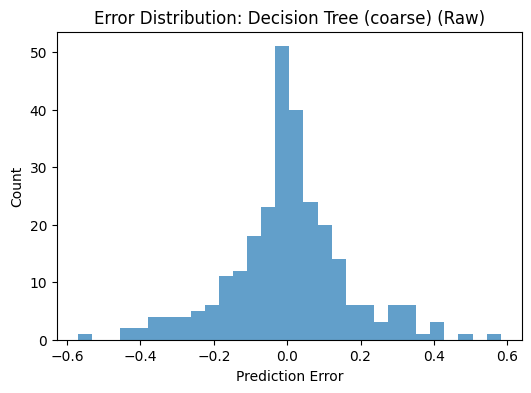

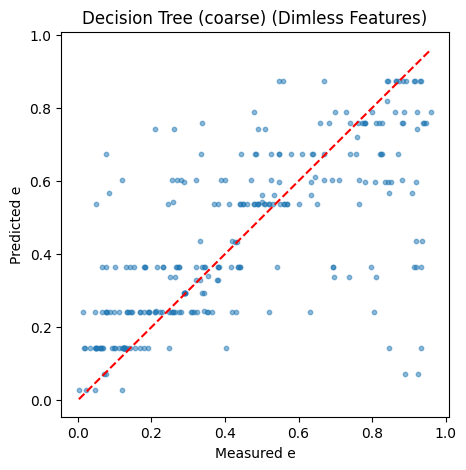

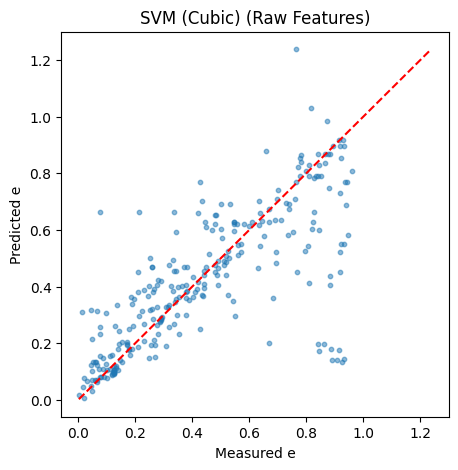

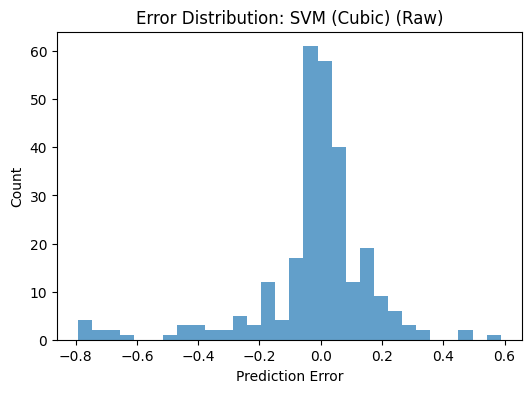

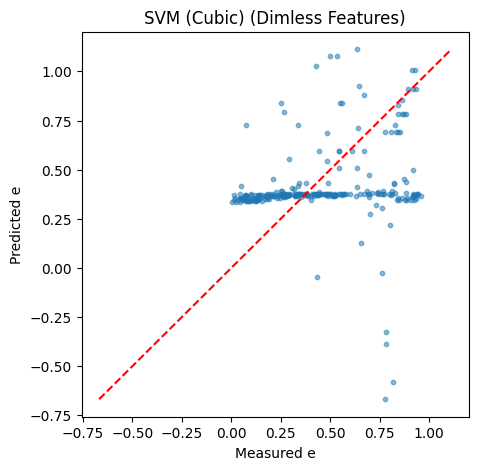

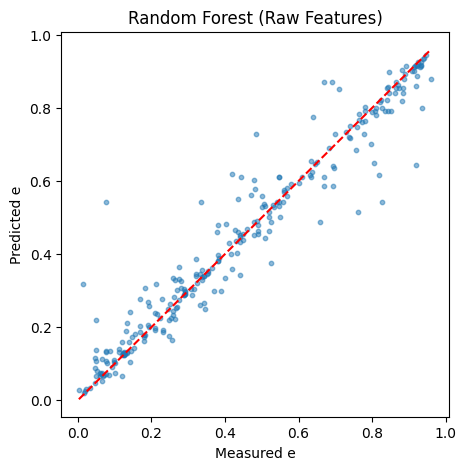

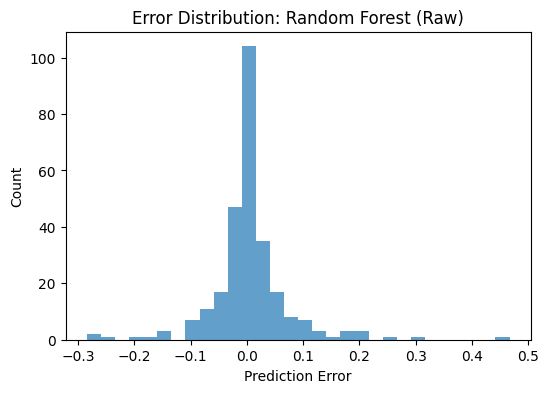

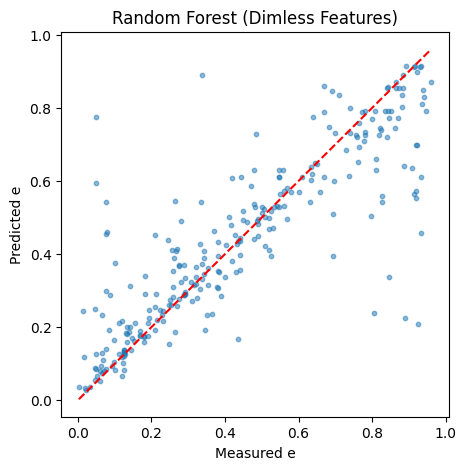

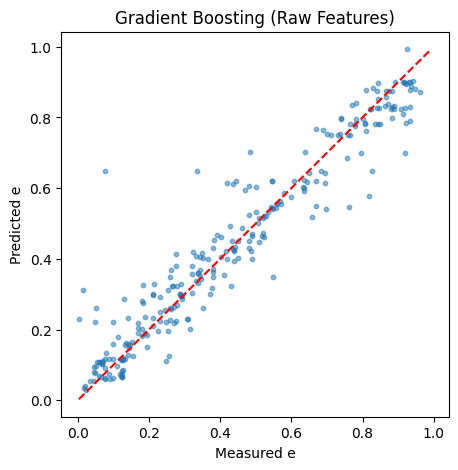

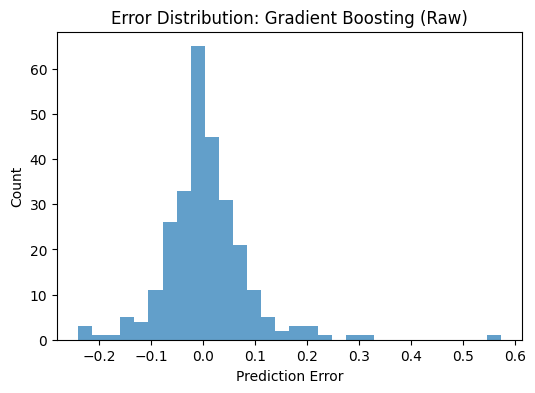

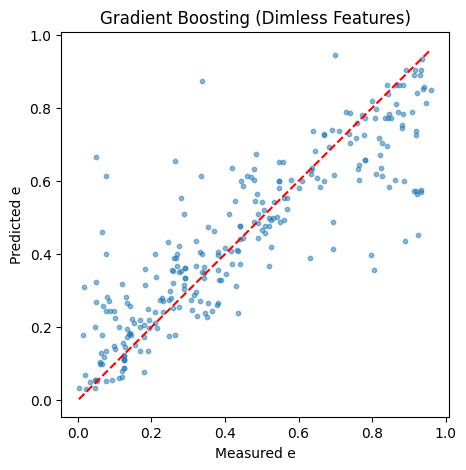

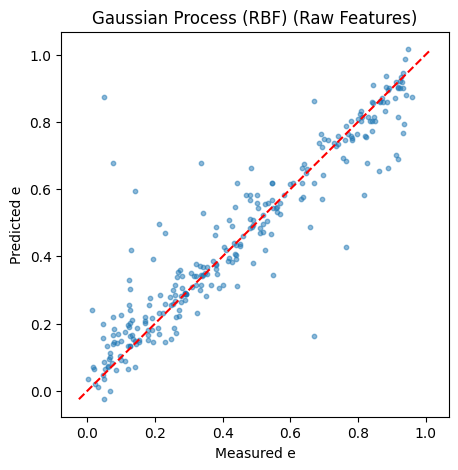

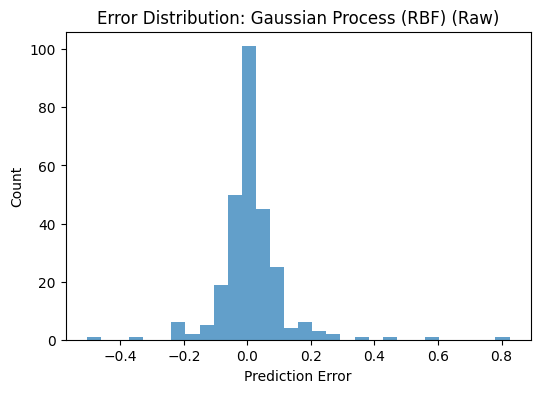

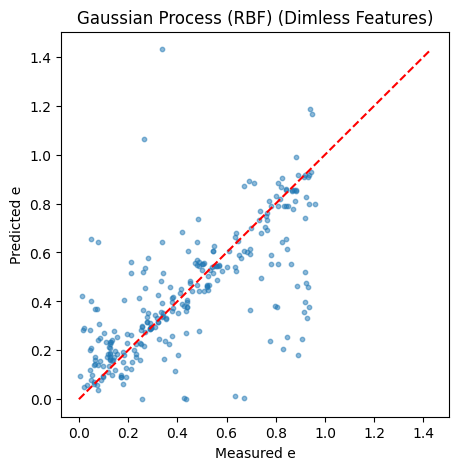

In [14]:
#make sure to define df and dim_df before this

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Make sure we have splits
RANDOM_STATE = 42

# Raw features
X_raw = df.drop(columns=["e"]).values
y      = df["e"].values

# Dimensionless features
X_dim = df_dim[["Re_l","Re_g","We_g"]].values

#Train test split 80/20
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE
)
X_train_dim, X_test_dim, y_train_dim, y_test_dim = train_test_split(
    X_dim, y, test_size=0.2, random_state=RANDOM_STATE
)

# helper functions
def make_estimator(obj):
    """Accepts either a bare estimator or a (estimator, needs_scaling) tuple."""
    if isinstance(obj, tuple):
        est, needs_scaling = obj
        return Pipeline([("scaler", StandardScaler()), ("model", est)]) if needs_scaling else est
    else:
        return obj

def y1d(yarr):
    yarr = np.asarray(yarr)
    return yarr.ravel() if yarr.ndim > 1 else yarr

def error_hist(y_true, y_pred, title):
    err = y_pred - y_true
    plt.figure(figsize=(6,4))
    plt.hist(err, bins=30, alpha=0.7)
    plt.title(f"Error Distribution: {title}")
    plt.xlabel("Prediction Error")
    plt.ylabel("Count")
    plt.show()

def reg_plot(y_true, y_pred, title):
    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred, alpha=0.5, s=10)
    mn = float(min(y_true.min(), y_pred.min()))
    mx = float(max(y_true.max(), y_pred.max()))
    plt.plot([mn, mx], [mn, mx], 'r--')
    plt.xlabel("Measured e")
    plt.ylabel("Predicted e")
    plt.title(title)
    plt.show()

# y must be 1D for sklearn
y_train_raw_1d = y1d(y_train_raw)
y_test_raw_1d  = y1d(y_test_raw)
y_train_dim_1d = y1d(y_train_dim)
y_test_dim_1d  = y1d(y_test_dim)

# Example:
# models = {
#   "Linear Regression": (LinearRegression(), True),
#   "Random Forest": (RandomForestRegressor(n_estimators=200, random_state=42), False),
#   ...
# }
for name, model_obj in models.items():
    # RAW features
    est = make_estimator(model_obj)
    est.fit(X_train_raw, y_train_raw_1d)
    y_pred_raw = est.predict(X_test_raw)
    reg_plot(y_test_raw_1d, y_pred_raw, f"{name} (Raw Features)")
    error_hist(y_test_raw_1d, y_pred_raw, f"{name} (Raw)")

    # DIMENSIONLESS features
    est = make_estimator(model_obj)  # fresh estimator each time
    est.fit(X_train_dim, y_train_dim_1d)
    y_pred_dim = est.predict(X_test_dim)
    reg_plot(y_test_dim_1d, y_pred_dim, f"{name} (Dimless Features)")


In [15]:
def fold_metrics(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    R    = np.corrcoef(y_true, y_pred)[0, 1] if (np.std(y_true)>0 and np.std(y_pred)>0) else np.nan
    return rmse, r2, mse, R

def kfold_eval(X, y, model, needs_scaling, n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rmses, r2s, mses, Rs = [], [], [], []
    for train_idx, test_idx in kf.split(X):
        Xtr, Xte = X[train_idx], X[test_idx]
        ytr, yte = y[train_idx], y[test_idx]
        pipe = make_pipeline_if_needed(model, needs_scaling)
        pipe.fit(Xtr, ytr)
        yhat = pipe.predict(Xte)
        rmse, r2, mse, R = fold_metrics(yte, yhat)
        rmses.append(rmse); r2s.append(r2); mses.append(mse); Rs.append(R)
    return {
        "RMSE_mean": np.mean(rmses), "RMSE_std": np.std(rmses, ddof=1),
        "R2_mean":   np.mean(r2s),   "R2_std":   np.std(r2s,   ddof=1),
        "MSE_mean":  np.mean(mses),  "MSE_std":  np.std(mses,  ddof=1),
        "R_mean":    np.mean(Rs),    "R_std":    np.std(Rs,    ddof=1),
    }

In [17]:
rows = []
for name, (estimator, need_scale) in models.items():
    # Raw
    m_raw = kfold_eval(X_raw, y, estimator, need_scale, n_splits=5, random_state=42)
    rows.append([name, "Raw", m_raw["RMSE_mean"], m_raw["RMSE_std"], m_raw["R_mean"], m_raw["R_std"],
                 m_raw["MSE_mean"], m_raw["MSE_std"], m_raw["R2_mean"], m_raw["R2_std"]])

    # Dimensionless
    m_dim = kfold_eval(X_dim, y, estimator, need_scale, n_splits=5, random_state=42)
    rows.append([name, "Dimensionless", m_dim["RMSE_mean"], m_dim["RMSE_std"], m_dim["R_mean"], m_dim["R_std"],
                 m_dim["MSE_mean"], m_dim["MSE_std"], m_dim["R2_mean"], m_dim["R2_std"]])

df_cv = pd.DataFrame(rows, columns=[
    "Method","Feature_Set",
    "RMSE_mean","RMSE_std",
    "R_mean","R_std",
    "MSE_mean","MSE_std",
    "R2_mean","R2_std"
])

# sort nicely: Raw first, lowest RMSE on top
df_cv["Feature_Set"] = pd.Categorical(df_cv["Feature_Set"], ["Raw","Dimensionless"])
df_cv = df_cv.sort_values(["Feature_Set","RMSE_mean"]).reset_index(drop=True)

# display
print(df_cv)

                    Method    Feature_Set  RMSE_mean  RMSE_std    R_mean  \
0            Random Forest            Raw   0.070444  0.001313  0.969951   
1        Gradient Boosting            Raw   0.082639  0.003771  0.959077   
2   Gaussian Process (RBF)            Raw   0.103911  0.005290  0.933529   
3   Decision Tree (coarse)            Raw   0.165629  0.005636  0.819268   
4              SVM (Cubic)            Raw   0.184944  0.020643  0.774296   
5        Linear Regression            Raw   0.246731  0.013836  0.520144   
6        Gradient Boosting  Dimensionless   0.142622  0.008899  0.870705   
7            Random Forest  Dimensionless   0.143707  0.018251  0.865166   
8   Decision Tree (coarse)  Dimensionless   0.197109  0.015573  0.732576   
9   Gaussian Process (RBF)  Dimensionless   0.201372  0.014831  0.737852   
10       Linear Regression  Dimensionless   0.259941  0.011137  0.435348   
11             SVM (Cubic)  Dimensionless   0.479486  0.361168  0.212319   

       R_st

In [18]:
paper_like = df_cv[df_cv["Feature_Set"]=="Raw"][["Method","RMSE_mean","R_mean","MSE_mean"]]
paper_like = paper_like.rename(columns={
    "RMSE_mean":"RMSE",
    "R_mean":"R",
    "MSE_mean":"MSE"
})
print("\nRegular ML for comparison (Raw only, KFold mean)")
print(paper_like)


Regular ML for comparison (Raw only, KFold mean)
                   Method      RMSE         R       MSE
0           Random Forest  0.070444  0.969951  0.004964
1       Gradient Boosting  0.082639  0.959077  0.006841
2  Gaussian Process (RBF)  0.103911  0.933529  0.010820
3  Decision Tree (coarse)  0.165629  0.819268  0.027458
4             SVM (Cubic)  0.184944  0.774296  0.034545
5       Linear Regression  0.246731  0.520144  0.061029


##### Classic ML results
raw variables carry more predictive detail than using only Re/We. Tree ensembles provide a good baseline


Predicted Vs. Actual
Regression scatterplots (y_true vs. y_pred) helps show model quality

Scaling inside each fold (via pipeline prevents leakage)

Compute Pearson R directly per fold and average it (matching how many papers report "R")

Can change n_splits=5 or random_state

In [ ]:
def reg_plot(y_true, y_pred, title):
    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred, alpha=0.5, s=10)
    mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    plt.plot([mn,mx],[mn,mx], 'r--')  # 45° line
    plt.xlabel("Measured e")
    plt.ylabel("Predicted e")
    plt.title(title)
    plt.show()

for name, model in models.items():
    # raw features
    model.fit(X_train_raw_scaled, y_train_raw)
    y_pred_raw = model.predict(X_test_raw_scaled)
    reg_plot(y_test_raw, y_pred_raw, f"{name} (Raw Features)")
    
    # dim features
    model.fit(X_train_dim_scaled, y_train_dim)
    y_pred_dim = model.predict(X_test_dim_scaled)
    reg_plot(y_test_dim, y_pred_dim, f"{name} (Dimless Features)")


Error distribution plots
Histograms of residuals highlight bias or skew

In [ ]:
def error_hist(y_true, y_pred, title):
    err = y_pred - y_true
    plt.figure(figsize=(6,4))
    plt.hist(err, bins=30, alpha=0.7)
    plt.title(f"Error Distribution: {title}")
    plt.xlabel("Prediction Error")
    plt.ylabel("Count")
    plt.show()

for name, model in models.items():
    # example for raw only
    model.fit(X_train_raw_scaled, y_train_raw)
    y_pred_raw = model.predict(X_test_raw_scaled)
    error_hist(y_test_raw, y_pred_raw, f"{name} (Raw)")


Cross-Validation
Added in K-fold CV

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
import warnings
warnings.filterwarnings("ignore")

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf = RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=400)

scores = cross_val_score(rf, X_raw, y, cv=cv, scoring="r2")
print("Kfold R² scores (Raw features):", scores)
print("Mean R²:", scores.mean())

Model generalizes well across all subsets of the data
On average, random forest model explains about 94.5% of the variance in entrainment fraction (e). Low variance between the folds, this tight spread means the model is stable it doesn't depend heavily on one fold or suffer from unstable splits.





TO DO: Compare with dimensionless features
If you run the same CV on Re_l, Re_g, We_g, you’ll likely see weaker and more variable performance. That gives you the storyline: raw features preserve more predictive detail than physics-compressed groups.

Discuss physics vs ML

Physics-based features (Re, We) are interpretable but lose accuracy.

ML baselines (RF/GBM) with raw features can capture ~95% of variance.

ANN baseline can then be compared against this strong RF result.

#### Baseline Ml results

Table: RMSE and R² side-by-side for all models and feature sets.

Figures: predicted vs actual scatterplots, error histograms.

Discussion: raw features outperform dimensionless features; tree ensembles outperform linear regression.

Next step: transition into ANN baseline and show whether it improves on the best ML baseline (RF).